# Donor retention & growth — classification pipeline (CRISP-DM)

**Organization context:** HealingWings / Lighthouse-style nonprofit; retention and “who is at risk of lapsing?” supports fundraising outreach.

**Artifacts in this folder**
- `donor_retention_churn.ipynb` (this notebook)
- `serialized_models/` — trained pipeline for deployment (Ch. 17; avoids repo `.gitignore` on `artifacts/`)
- **Shared (parent `ml-pipelines/`):** `../requirements.txt` — Python dependencies for all pipeline notebooks

**Data source:** CSV extracts under `data/lighthouse_csv_v7/` at the repo root. The setup cell walks up from the notebook cwd until it finds the repo root (markers: `ml-pipelines/` + `data/lighthouse_csv_v7/`), then sets `DATA_DIR`.

**Related pipeline:** resident case risk — `../resident_case_progress/resident_elevated_risk.ipynb`.

This notebook follows **CRISP-DM** and **IS 455 – Machine Learning**: end-to-end pipeline thinking (problem framing through deployment), explicit **predictive vs explanatory** modeling, rigorous validation, business interpretation, and a written **production integration** plan (Ch. 17).

## Phase 1 — Business understanding (Ch. 1)

**Problem:** Leadership loses donors without clear warning and lacks bandwidth for personalized outreach. They need a **prioritized list of supporters who are likely to stop giving** so staff can intervene early.

**Analytics goal (this notebook):** Build a **supervised classification model** at the **supporter** level.

**Prediction vs. explanation (textbook framing):**  
- **Primary emphasis — predictive:** Generalize to unseen supporters using held-out evaluation; optimize metrics that reflect outreach capacity (precision/recall tradeoffs).  
- **Secondary — explanatory:** We interpret feature importances and simple baseline coefficients *descriptively* (correlation / partial dependence — **not** causal claims).

**Target definition (behavioral churn, leakage-safe):**  
Let **observation date** = latest `donation_date` in the extract. We compare two consecutive 365-day windows:
- **Prior feature window:** \((\text{obs} - 730\text{d}, \text{obs} - 365\text{d}]\)  
- **Recent outcome window:** \((\text{obs} - 365\text{d}, \text{obs}]\)

**Eligibility:** Supporters with **at least one Monetary** gift in the *prior* window (they demonstrated monetary engagement before the outcome window).

**Label `churned = 1`:** No **Monetary** donation in the *recent* outcome window (lapsed monetary giving). **`churned = 0`:** At least one Monetary gift in that window.

**Business costs of errors:**  
- **False positive** (predict churn, donor would have stayed): extra touchpoint — usually acceptable.  
- **False negative** (miss a lapser): **lost revenue** and weaker relationship — typically the more costly error for a donation-funded nonprofit.

**Metrics:** Report ROC-AUC, precision/recall, and confusion counts **in plain language** for fundraising staff.

### Alignment with IS 455 (full pipeline lifecycle)

| Requirement | How this notebook addresses it |
|---------------|--------------------------------|
| **Problem framing (Ch. 1)** | Business question, success metrics, **predictive vs explanatory** goals stated explicitly below and in Phase 4b. |
| **Data prep (Ch. 2–5, 7)** | Reproducible CSV → feature table; time windows prevent label leakage. |
| **Exploration (Ch. 6, 8)** | Distributions, crosstabs, correlation heatmap among numeric features. |
| **Modeling (Ch. 9–14)** | **Explanatory:** logistic regression (interpretable associations). **Predictive:** trees, forests, boosting, voting ensemble; RF tuned with CV. |
| **Evaluation (Ch. 15)** | Stratified train/test, **CV on training only** for comparing models and tuning; holdout used for final reporting; business interpretation; fairness slice. |
| **Feature selection (Ch. 16)** | Importances + `SelectFromModel` on tuned forest. |
| **Deployment (Ch. 17)** | `joblib` pipeline + metadata; written integration plan (API / admin UI) — production wiring is a **team** deliverable. |

**“Causal” vs predictive (course language):** We report a **logistic (associational) model** for **explanation** — coefficients describe relationships *conditional on other features in the model*, not proven causes. The **random forest** (tuned) is the primary **predictive** artifact for operations (risk scores).

## Phase 2 — Data understanding (Ch. 2, 6, 8)

**Tables used**
| Table | Role |
|-------|------|
| `supporters` | Entity grain; demographics / acquisition / CRM `status` |
| `donations` | Events; amount, type, campaign, channel, `referral_post_id` |
| `donation_allocations` | Links donations to `safehouse_id` & `program_area` |
| `social_media_posts` | Enrichment for social-attributed gifts |
| `safehouses` | Joined via allocations for geographic / capacity context (if present) |
| `in_kind_donation_items` | Loaded for parity with domain schema; optional extension |

We **do not** use direct PII (email, phone, free-text names) as model inputs.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)

# Repo paths (cwd may be repo root, ml-pipelines/, or donor_retention/)
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for d in [p, *p.parents]:
        if (d / "ml-pipelines").is_dir() and (d / "data" / "lighthouse_csv_v7").is_dir():
            return d
    raise FileNotFoundError(
        "Could not find repo root (need ml-pipelines/ and data/lighthouse_csv_v7/). "
        f"cwd={p}"
    )

REPO_ROOT = _find_repo_root(Path.cwd())
ML_PIPELINES_DIR = REPO_ROOT / "ml-pipelines"
DATA_DIR = REPO_ROOT / "data" / "lighthouse_csv_v7"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Missing data directory: {DATA_DIR}")

SERIALIZED_DIR = ML_PIPELINES_DIR / "donor_retention" / "serialized_models"
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)
print("SERIALIZED_DIR:", SERIALIZED_DIR)

REPO_ROOT: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5
DATA_DIR: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/data/lighthouse_csv_v7
SERIALIZED_DIR: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml-pipelines/donor_retention/serialized_models


In [2]:
def load_tables(data_dir: Path) -> dict[str, pd.DataFrame]:
    tables = {}
    for name in [
        "supporters",
        "donations",
        "donation_allocations",
        "social_media_posts",
        "safehouses",
        "in_kind_donation_items",
    ]:
        fp = data_dir / f"{name}.csv"
        if fp.exists():
            tables[name] = pd.read_csv(fp)
        else:
            tables[name] = pd.DataFrame()
    # Parse dates
    if not tables["donations"].empty and "donation_date" in tables["donations"].columns:
        tables["donations"]["donation_date"] = pd.to_datetime(tables["donations"]["donation_date"])
    if not tables["supporters"].empty:
        for c in ("created_at", "first_donation_date"):
            if c in tables["supporters"].columns:
                tables["supporters"][c] = pd.to_datetime(tables["supporters"][c], errors="coerce")
    if not tables["donation_allocations"].empty and "allocation_date" in tables["donation_allocations"].columns:
        tables["donation_allocations"]["allocation_date"] = pd.to_datetime(
            tables["donation_allocations"]["allocation_date"], errors="coerce"
        )
    if not tables["social_media_posts"].empty and "created_at" in tables["social_media_posts"].columns:
        tables["social_media_posts"]["created_at"] = pd.to_datetime(
            tables["social_media_posts"]["created_at"], errors="coerce"
        )
    return tables

tables = load_tables(DATA_DIR)
for k, v in tables.items():
    print(f"{k:24} shape={v.shape}")

supporters               shape=(60, 15)
donations                shape=(420, 13)
donation_allocations     shape=(521, 7)
social_media_posts       shape=(812, 39)
safehouses               shape=(9, 13)
in_kind_donation_items   shape=(129, 9)


In [3]:
don = tables["donations"].copy()
sup = tables["supporters"].copy()
alloc = tables["donation_allocations"].copy()
posts = tables["social_media_posts"].copy()
houses = tables["safehouses"].copy()
# Optional: merge safehouse region into allocation features
if not houses.empty and "safehouse_id" in houses.columns and "region" in houses.columns:
    house_reg = houses[["safehouse_id", "region"]].drop_duplicates()
else:
    house_reg = pd.DataFrame()

obs_date = don["donation_date"].max()
prior_start = obs_date - pd.Timedelta(days=730)
prior_end = obs_date - pd.Timedelta(days=365)
recent_start = prior_end
recent_end = obs_date

print("Observation date:", obs_date.date())
print("Feature window (donations in):", prior_start.date(), "to", prior_end.date())
print("Outcome window (monetary activity):", recent_start.date(), "to", recent_end.date())

mon = don[don["donation_type"] == "Monetary"].copy()

def in_interval(df, col, left, right, closed_right=True):
    if closed_right:
        return df[(df[col] > left) & (df[col] <= right)]
    return df[(df[col] >= left) & (df[col] < right)]

prior_mon = in_interval(mon, "donation_date", prior_start, prior_end)
recent_mon = in_interval(mon, "donation_date", recent_start, recent_end)

eligible_ids = set(prior_mon["supporter_id"].unique())
recent_ids = set(recent_mon["supporter_id"].unique())
print("Eligible supporters (monetary in prior year):", len(eligible_ids))

labels = []
for sid in eligible_ids:
    labels.append({"supporter_id": sid, "churned": 0 if sid in recent_ids else 1})
label_df = pd.DataFrame(labels)
print(label_df["churned"].value_counts().sort_index())

Observation date: 2026-03-01
Feature window (donations in): 2024-03-01 to 2025-03-01
Outcome window (monetary activity): 2025-03-01 to 2026-03-01
Eligible supporters (monetary in prior year): 43
churned
0    33
1    10
Name: count, dtype: int64


### Univariate & bivariate exploration (Ch. 6, 8)

Examine donation intensity, types, and relationships before modeling. Patterns here inform feature engineering (e.g., channel diversity, social-attributed gifts).

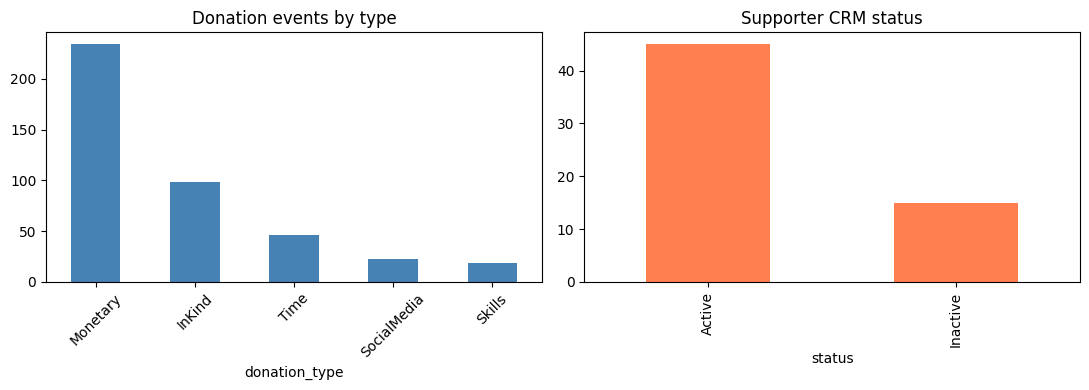

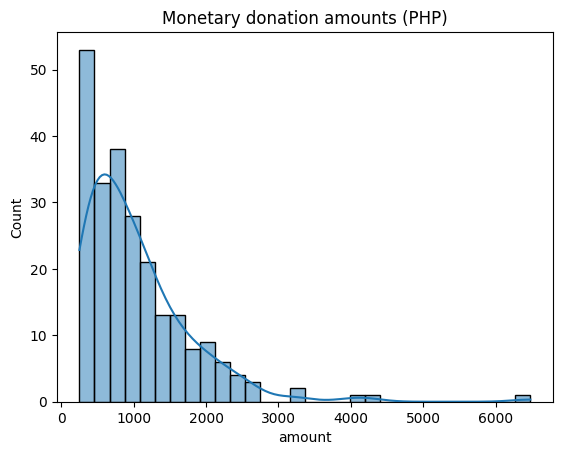


 supporter_type vs has any donation:
 n_all_gifts          False  True 
supporter_type                   
InKindDonor              0     15
MonetaryDonor            0     17
PartnerOrganization      0      4
SkillsContributor        0      6
SocialMediaAdvocate      0     10
Volunteer                1      7

 status vs has any donation:
 n_all_gifts  False  True 
status                   
Active           1     44
Inactive         0     15


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
don["donation_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Donation events by type")
axes[0].tick_params(axis="x", rotation=45)
sup["status"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Supporter CRM status")
plt.tight_layout()
plt.show()

# Monetary gift sizes
mamt = mon["amount"].astype(float)
sns.histplot(mamt.dropna(), bins=30, kde=True)
plt.title("Monetary donation amounts (PHP)")
plt.show()

# Correlation among supporter-level aggregates (built next in prep — preview raw donation counts per supporter)
pc = don.groupby("supporter_id").size().rename("n_all_gifts")
merged_prev = sup.merge(pc, on="supporter_id", how="left")
cat_cols = ["supporter_type", "status"]
for c in cat_cols:
    if c in merged_prev.columns:
        ct = pd.crosstab(merged_prev[c], merged_prev["n_all_gifts"].fillna(0) > 0, margins=False)
        print("\n", c, "vs has any donation:\n", ct.head(10))

## Phase 3 — Data preparation & wrangling (Ch. 2–4, 7)

**Reproducibility:** All features are computed from CSV loads and deterministic time windows — no manual Excel steps.

**Leakage control:** Supporter-level features use **only** donations with `donation_date` in the **prior** feature window (and static supporter fields known at `prior_end`). The **label** uses only the **subsequent** outcome window.

Feature matrix: (43, 26)  churn rate: 0.233


,supporter_id,churned,tenure_days_at_prior_end,monetary_count_prior,monetary_sum_prior,monetary_mean_prior,days_since_last_monetary_at_prior_end,n_distinct_channels
0,1,0,1155,2,1419.33,709.665,80,2
1,3,0,1145,4,4318.96,1079.740,83,3
2,4,0,1140,2,2640.77,1320.385,141,3
3,5,0,1135,2,2211.65,1105.825,63,2
4,6,0,1130,3,2985.45,995.150,14,2


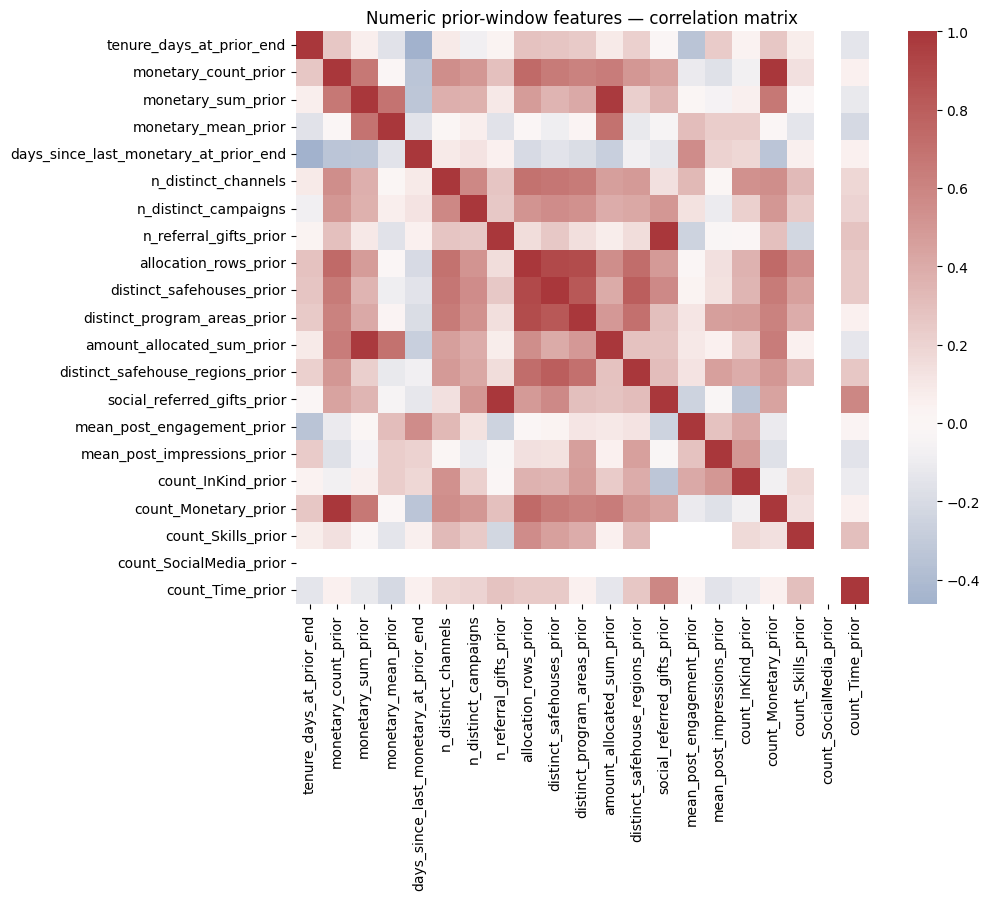

In [5]:
def window_mask(series: pd.Series, left, right) -> pd.Series:
    return (series > left) & (series <= right)

prior_don = don[window_mask(don["donation_date"], prior_start, prior_end)].copy()
prior_mon_w = prior_don[prior_don["donation_type"] == "Monetary"].copy()

# Monetary aggregates (prior window)
g_m = prior_mon_w.groupby("supporter_id").agg(
    monetary_count_prior=("donation_id", "count"),
    monetary_sum_prior=("amount", lambda s: pd.to_numeric(s, errors="coerce").sum()),
    monetary_mean_prior=("amount", lambda s: pd.to_numeric(s, errors="coerce").mean()),
).reset_index()

last_m_prior = prior_mon_w.sort_values("donation_date").groupby("supporter_id").tail(1)
last_m_prior = last_m_prior[["supporter_id", "donation_date"]].rename(columns={"donation_date": "last_monetary_prior"})
g_m = g_m.merge(last_m_prior, on="supporter_id", how="left")
g_m["days_since_last_monetary_at_prior_end"] = (prior_end - g_m["last_monetary_prior"]).dt.days

# All-type counts in prior window
type_counts = prior_don.pivot_table(
    index="supporter_id", columns="donation_type", values="donation_id", aggfunc="count", fill_value=0
)
type_counts = type_counts.rename(columns=lambda c: f"count_{c}_prior")
type_counts = type_counts.reset_index()

# Channel & campaign diversity
def nunique_non_empty(s: pd.Series) -> int:
    t = s.astype(str).str.strip()
    t = t.replace("", np.nan)
    return t.nunique(dropna=True)

ch = prior_don.groupby("supporter_id").agg(
    n_distinct_channels=("channel_source", lambda s: s.astype(str).nunique()),
    n_distinct_campaigns=("campaign_name", nunique_non_empty),
    n_referral_gifts_prior=("referral_post_id", lambda s: s.notna().sum()),
).reset_index()

# Allocations (prior window): join to donation dates
alloc_f = alloc.merge(don[["donation_id", "donation_date", "supporter_id"]], on="donation_id", how="left")
alloc_prior = alloc_f[window_mask(alloc_f["donation_date"], prior_start, prior_end)]
alloc_feats = alloc_prior.groupby("supporter_id").agg(
    allocation_rows_prior=("allocation_id", "count"),
    distinct_safehouses_prior=("safehouse_id", pd.Series.nunique),
    distinct_program_areas_prior=("program_area", lambda s: s.astype(str).nunique()),
    amount_allocated_sum_prior=("amount_allocated", lambda s: pd.to_numeric(s, errors="coerce").sum()),
).reset_index()
if not house_reg.empty:
    ap2 = alloc_prior.merge(house_reg, on="safehouse_id", how="left")
    reg_counts = ap2.groupby("supporter_id")["region"].nunique(dropna=True).rename("distinct_safehouse_regions_prior")
    alloc_feats = alloc_feats.merge(reg_counts.reset_index(), on="supporter_id", how="left")

# Social enrichment: donations that cite a post
ref_prior = prior_don[prior_don["referral_post_id"].notna()]
sp = ref_prior.merge(
    posts,
    left_on="referral_post_id",
    right_on="post_id",
    how="left",
    suffixes=("", "_post"),
)
if not sp.empty:
    soc = sp.groupby("supporter_id").agg(
        social_referred_gifts_prior=("donation_id", "count"),
        mean_post_engagement_prior=("engagement_rate", lambda x: pd.to_numeric(x, errors="coerce").mean()),
        mean_post_impressions_prior=("impressions", lambda x: pd.to_numeric(x, errors="coerce").mean()),
    ).reset_index()
else:
    soc = pd.DataFrame({"supporter_id": sorted(eligible_ids)})
    for c in ["social_referred_gifts_prior", "mean_post_engagement_prior", "mean_post_impressions_prior"]:
        soc[c] = 0.0

# Static supporter fields (as of prior_end)
stat = sup.copy()
stat["tenure_days_at_prior_end"] = (prior_end - stat["created_at"]).dt.days

feat = stat[stat["supporter_id"].isin(eligible_ids)].copy()
for df_extra in [g_m, type_counts, ch, alloc_feats, soc]:
    feat = feat.merge(df_extra, on="supporter_id", how="left")

feat = feat.merge(label_df, on="supporter_id", how="inner")

num_cols = [
    "tenure_days_at_prior_end",
    "monetary_count_prior",
    "monetary_sum_prior",
    "monetary_mean_prior",
    "days_since_last_monetary_at_prior_end",
    "n_distinct_channels",
    "n_distinct_campaigns",
    "n_referral_gifts_prior",
    "allocation_rows_prior",
    "distinct_safehouses_prior",
    "distinct_program_areas_prior",
    "amount_allocated_sum_prior",
    "distinct_safehouse_regions_prior",
    "social_referred_gifts_prior",
    "mean_post_engagement_prior",
    "mean_post_impressions_prior",
]
# Add dynamic count_* columns from pivot
num_cols += [c for c in feat.columns if c.startswith("count_") and c.endswith("_prior")]
num_cols = [c for c in num_cols if c in feat.columns]

cat_cols = [c for c in ["supporter_type", "relationship_type", "region", "country", "acquisition_channel"] if c in feat.columns]

feat[num_cols] = feat[num_cols].apply(pd.to_numeric, errors="coerce")
X = feat[num_cols + cat_cols].copy()
y = feat["churned"].astype(int)

print("Feature matrix:", X.shape, " churn rate:", y.mean().round(3))
display(feat[["supporter_id", "churned"] + num_cols[:6]].head())

# Ch. 6 / 8 — correlation structure among numeric engagement features (no labels)
corr = X[num_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, square=True)
plt.title("Numeric prior-window features — correlation matrix")
plt.tight_layout()
plt.show()

## Phase 4 — Modeling (Ch. 13 classification, Ch. 14 ensembles)

**Two modeling goals (IS 455):**
- **Predictive:** rank supporters by estimated lapse risk for outreach (prioritize generalization; holdout + CV).
- **Explanatory / associational:** logistic regression on the same features to discuss **direction and relative magnitude** of relationships — **not** causal inference (unobserved confounding, reverse causality, small *n*).

We compare:
- **Logistic regression** — used both in the sweep and expanded in **Phase 4b** for interpretation
- **Decision tree** (transparent splits)
- **Random forest** & **histogram gradient boosting** (ensembles)
- **Soft-voting** LR + RF (separate preprocessing clones)

**Validation discipline (Ch. 15):** **80/20 stratified train/test.** Model **selection** among the above uses **cross-validated ROC-AUC on the training set only** (no peeking at the test set). **Hyperparameter tuning** for the deployment forest also uses CV on training. The **test set** is used **once** for reporting after choices are fixed.

In [6]:
RANDOM_STATE = 42
cv_splits = 3 if len(y) < 30 else 5
cv_sel = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
feat_train = feat.iloc[idx_train].reset_index(drop=True)
feat_test = feat.iloc[idx_test].reset_index(drop=True)

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

models = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.05, max_iter=200, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

results = []
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("model", clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv_sel, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    proba_te = pipe.predict_proba(X_test)[:, 1]
    results.append(
        {
            "model": name,
            "cv_roc_auc_mean": cv_auc.mean(),
            "cv_roc_auc_std": cv_auc.std(),
            "holdout_roc_auc": roc_auc_score(y_test, proba_te),
        }
    )
    fitted[name] = pipe

pipe_lr = Pipeline(
    [
        ("prep", clone(preprocess)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
pipe_rf = Pipeline(
    [
        ("prep", clone(preprocess)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)
voting = VotingClassifier(estimators=[("lr", pipe_lr), ("rf", pipe_rf)], voting="soft")
cv_auc_v = cross_val_score(voting, X_train, y_train, cv=cv_sel, scoring="roc_auc", n_jobs=-1)
voting.fit(X_train, y_train)
proba_v = voting.predict_proba(X_test)[:, 1]
results.append(
    {
        "model": "voting_lr_rf",
        "cv_roc_auc_mean": cv_auc_v.mean(),
        "cv_roc_auc_std": cv_auc_v.std(),
        "holdout_roc_auc": roc_auc_score(y_test, proba_v),
    }
)
fitted["voting_lr_rf"] = voting

res_df = pd.DataFrame(results).sort_values("cv_roc_auc_mean", ascending=False)
display(res_df)

best_name = res_df.iloc[0]["model"]
print("Selected for Phase 5 plots (highest mean CV ROC-AUC on training only):", best_name)
print("(Holdout column is reported for transparency — it was not used to pick the model.)")

,model,cv_roc_auc_mean,cv_roc_auc_std,holdout_roc_auc
0,logistic_regression,0.580000,0.331059,0.642857
4,voting_lr_rf,0.580000,0.337046,0.642857
2,random_forest,0.566667,0.306232,0.642857
1,decision_tree,0.523333,0.247341,0.678571
3,hist_gradient_boosting,0.500000,0.000000,0.500000


Selected for Phase 5 plots (highest mean CV ROC-AUC on training only): logistic_regression
(Holdout column is reported for transparency — it was not used to pick the model.)


### Phase 4b — Explanatory (associational) model — Ch. 9–11 / 13 framing

**Goal:** Summarize **which features move the log-odds of lapse** in a **linear-in-features** model. This supports **storytelling and prioritization** (e.g., “donors with lower recent monetary frequency look more likely to lapse in our snapshot”), not **causal** claims.

**Caveats:** Coefficients are **marginal associations** after controlling for other included fields; omitted variables, measurement error, and reverse causality can distort interpretation — especially with **small *n***.

We fit **logistic regression** on **training data only** and inspect standardized numeric inputs + one-hot categories.

In [7]:
expl_pipe = Pipeline(
    [
        ("prep", clone(preprocess)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
expl_pipe.fit(X_train, y_train)
expl_fnames = list(expl_pipe.named_steps["prep"].get_feature_names_out())
coefs = expl_pipe.named_steps["model"].coef_.ravel()
summary = (
    pd.DataFrame({"feature": expl_fnames, "logistic_coef": coefs})
    .assign(abs_coef=lambda d: d["logistic_coef"].abs())
    .sort_values("abs_coef", ascending=False)
)
print("Top 25 |coefficient| (associational logistic; train fit):")
display(summary.head(25))

print(
    "\nDecision hints (if associations persist after monitoring — not prescriptions):\n"
    "- Negative coef on engagement/recency features → higher values linked to *lower* log-odds of lapse in this model.\n"
    "- Use these as hypotheses for segmented stewardship (e.g., re-engage low-frequency monetary donors), then test with experiments."
)

Top 25 |coefficient| (associational logistic; train fit):


,feature,logistic_coef,abs_coef
7,num__n_referral_gifts_prior,-1.179054,1.179054
10,num__distinct_program_areas_prior,0.779316,0.779316
30,cat__region_Luzon,0.739585,0.739585
6,num__n_distinct_campaigns,0.615347,0.615347
1,num__monetary_count_prior,-0.579989,0.579989
17,num__count_Monetary_prior,-0.579989,0.579989
4,num__days_since_last_monetary_at_prior_end,-0.579248,0.579248
36,cat__country_USA,-0.573530,0.573530
22,cat__supporter_type_MonetaryDonor,-0.552711,0.552711
26,cat__supporter_type_Volunteer,0.549852,0.549852



Decision hints (if associations persist after monitoring — not prescriptions):
- Negative coef on engagement/recency features → higher values linked to *lower* log-odds of lapse in this model.
- Use these as hypotheses for segmented stewardship (e.g., re-engage low-frequency monetary donors), then test with experiments.


### Causal and relationship analysis (IS 455 narrative)

**What we can say:** Random forest **importance** and logistic **coefficients** highlight **co-movements** between engineered engagement features and lapse in this historical window. They are useful for **hypothesis generation** (e.g., diversify channels, steward after long gaps).

**What we cannot say:** We **do not** claim that changing one lever *causes* retention to improve. Donor behavior is driven by unmeasured motivation, economics, and life events.

**False positives / false negatives (fundraising context):** A **false positive** wastes a touchpoint; a **false negative** risks losing a donor — align thresholds with **capacity** and **cost of contact** when deploying scores.

**Next evidence:** A/B outreach tests, richer consent-based attributes, and periodic **recalibration** as new campaigns and social posts enter the data.

## Phase 5 — Evaluation, selection & tuning (Ch. 15)

We report **ROC-AUC** (ranking quality for prioritization), **precision/recall** at 0.5 threshold, and a **confusion matrix**. For nonprofits, emphasize **recall for churners** if missing lapsers is costly — you can lower the probability threshold in production.

**Discipline:** The model highlighted below was chosen using **CV on training data** (Phase 4). The **test set** here is for **final reporting** of that choice, not for cherry-picking among many alternatives.

**Fairness check (illustrative):** With tiny samples, we only **inspect** whether predicted risk vs. observed churn differs across `supporter_type` on test rows — not a full fairness audit.

              precision    recall  f1-score   support

      active       0.83      0.71      0.77         7
     churned       0.33      0.50      0.40         2

    accuracy                           0.67         9
   macro avg       0.58      0.61      0.58         9
weighted avg       0.72      0.67      0.69         9

ROC-AUC: 0.643


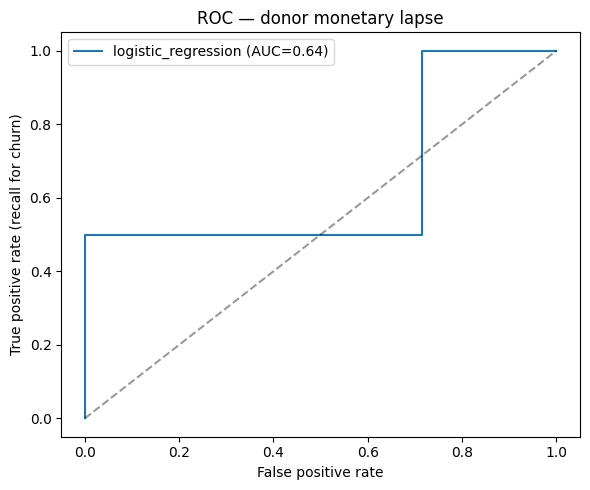

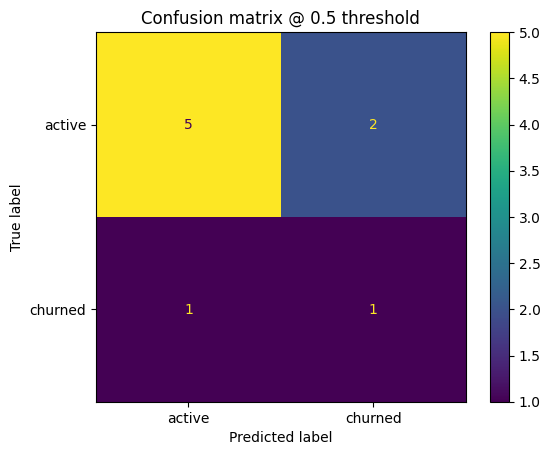


Confusion counts:
 predicted  0  1
actual         
0          5  2
1          1  1

Interpretation: 'churned' positive class = monetary lapse in recent year. False negatives are donors we failed to flag before they stopped giving in that window.

Test rows: churn rate vs mean predicted P(lapse) by supporter_type


,n,churn_rate,mean_p_churn
supporter_type,,,
InKindDonor,4,0.25,0.3052
MonetaryDonor,2,0.50,0.4839
SkillsContributor,1,0.00,0.7761
SocialMediaAdvocate,1,0.00,0.1388
Volunteer,1,0.00,0.0050


In [8]:
best_pipe = fitted[best_name]
proba = best_pipe.predict_proba(X_test)[:, 1]
y_hat = (proba >= 0.5).astype(int)

print(classification_report(y_test, y_hat, target_names=["active", "churned"]))
print("ROC-AUC:", round(float(roc_auc_score(y_test, proba)), 3))

fpr, tpr, thr = roc_curve(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC={roc_auc_score(y_test, proba):.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall for churn)")
plt.title("ROC — donor monetary lapse")
plt.legend()
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_hat, display_labels=["active", "churned"])
plt.title("Confusion matrix @ 0.5 threshold")
plt.show()

# Business readout
cm = pd.crosstab(pd.Series(y_test.values, name="actual"), pd.Series(y_hat, name="predicted"))
print("\nConfusion counts:\n", cm)
print(
    "\nInterpretation: 'churned' positive class = monetary lapse in recent year. "
    "False negatives are donors we failed to flag before they stopped giving in that window."
)

# Fairness-style subgroup view (Ch. 15) — small n; for transparency only
ft = feat_test.reset_index(drop=True).copy()
ft["p_churn"] = proba
if "supporter_type" in ft.columns:
    print("\nTest rows: churn rate vs mean predicted P(lapse) by supporter_type")
    display(
        ft.groupby("supporter_type", dropna=False)
        .agg(n=("churned", "size"), churn_rate=("churned", "mean"), mean_p_churn=("p_churn", "mean"))
        .round(4)
    )

In [9]:
# Hyperparameter tuning on the strongest single estimator family (Random Forest)
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 6, None],
    "model__min_samples_leaf": [1, 2],
}

base_rf = Pipeline(
    [
        ("prep", clone(preprocess)),
        (
            "model",
            RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        ),
    ]
)

cv_splits = 3 if len(y_train) < 30 else 5
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    base_rf,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(float(grid.best_score_), 4))
print("Best params:", grid.best_params_)

tuned_proba = grid.predict_proba(X_test)[:, 1]
print("Holdout ROC-AUC after tuning:", round(float(roc_auc_score(y_test, tuned_proba)), 4))
best_deploy_pipe = grid.best_estimator_

Best CV ROC-AUC: 0.5667
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Holdout ROC-AUC after tuning: 0.5714


## Phase 5b — Feature selection (Ch. 16)

We inspect **permutation-style importance via tree `feature_importances_`** on the **full transformed feature space** (numeric + one-hot). **`SelectFromModel`** with the median threshold shows how aggressively we could prune while keeping a deployable forest; with small *n*, pruning is mainly illustrative.

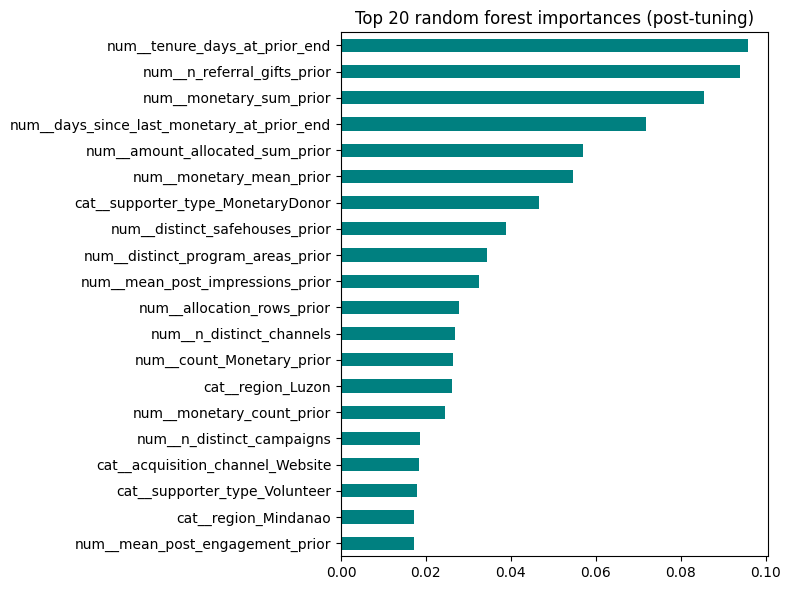

,importance
num__tenure_days_at_prior_end,0.095804
num__n_referral_gifts_prior,0.093908
num__monetary_sum_prior,0.085433
num__days_since_last_monetary_at_prior_end,0.071716
num__amount_allocated_sum_prior,0.057029
num__monetary_mean_prior,0.054551
cat__supporter_type_MonetaryDonor,0.046667
num__distinct_safehouses_prior,0.038861
num__distinct_program_areas_prior,0.034353
num__mean_post_impressions_prior,0.032392


Features kept by median-importance threshold: 22 / 43


In [10]:
prep_fitted = best_deploy_pipe.named_steps["prep"]
model_fitted = best_deploy_pipe.named_steps["model"]
fnames = list(prep_fitted.get_feature_names_out())
imp = pd.Series(model_fitted.feature_importances_, index=fnames).sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
imp.sort_values().plot(kind="barh", color="teal")
plt.title("Top 20 random forest importances (post-tuning)")
plt.tight_layout()
plt.show()
display(imp.to_frame("importance"))

selector = SelectFromModel(model_fitted, prefit=True, threshold="median")
print("Features kept by median-importance threshold:", selector.get_support().sum(), "/", len(fnames))

## Phase 6 — Deployment (Ch. 17) — production integration

IS 455 expects the model to **leave the notebook**: predictions or scores should reach **staff** through the **web app** (API, dashboard, or admin tool).

**What is done here**
- **`donor_churn_pipeline.joblib`**: tuned **random forest** `Pipeline` (`prep` + classifier) — use this for **operational risk scores** (`predict_proba` positive class = lapse).
- **`donor_churn_metadata.json`**: feature lists, date windows, label definition — keep in sync when retraining.

**Team integration options (pick one for the rubric)**
1. **ASP.NET endpoint** (e.g. `POST /api/ml/donor-churn/score`) that loads the same row shape as `X` (no PII in payload if possible), runs the serialized pipeline via **Python worker**, **ONNX export**, or **re-implemented** transforms.
2. **Batch scoring job** (nightly) writing `churn_risk_score` into the app database for an **Admin “at-risk donors”** table.
3. **Azure ML / container** hosting the model; API called from the backend with service auth.

**Security / privacy:** Score only **authenticated admin** routes; log aggregates, not raw donor narratives; align with GDPR consent for use of engagement attributes.

**Monitoring:** Track score distribution drift and **calibration** over time; refresh windows as new donations arrive.

In [11]:
metadata = {
    "observation_date": str(obs_date.date()),
    "prior_feature_window": [str(prior_start.date()), str(prior_end.date())],
    "outcome_window": [str(recent_start.date()), str(recent_end.date())],
    "label": "churned=1 if no Monetary gift in outcome window among supporters with Monetary gift in prior window",
    "numeric_features": num_cols,
    "categorical_features": cat_cols,
    "best_grid_params": grid.best_params_,
    "deployment_model": "Tuned RandomForestClassifier Pipeline (predictive). Logistic pipeline in notebook for explanatory coefficients only.",
}

joblib.dump(best_deploy_pipe, SERIALIZED_DIR / "donor_churn_pipeline.joblib")
with open(SERIALIZED_DIR / "donor_churn_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", SERIALIZED_DIR / "donor_churn_pipeline.joblib")
print("Saved:", SERIALIZED_DIR / "donor_churn_metadata.json")

Saved: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml-pipelines/donor_retention/serialized_models/donor_churn_pipeline.joblib
Saved: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml-pipelines/donor_retention/serialized_models/donor_churn_metadata.json


### Limitations & next steps

- **Small sample (*n*≈40+ eligible supporters):** Metrics are noisy; prioritize **stability** (CV) and **transparent features** over peak AUC.
- **Snapshot data:** Refresh labels as new donations arrive (rolling windows).
- **Integration:** Expose `predict_proba` via authenticated admin API; never expose raw PII externally.
- **Fairness:** Review errors by `region` / `supporter_type` if outreach policies could skew impact.

**CRISP-DM loop:** Deploy → monitor calibration → collect feedback from fundraising → revisit business definition (threshold, window length) → retrain.